In [1]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms
from torchvision.utils import save_image

import numpy as np
import datetime
import os, sys

import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow, imsave
%matplotlib inline

from tqdm.auto import tqdm
import glob
from PIL import Image

/home/ncvescera/Documents/UniPG/PhD/tutor/lezioni/Machine_Learning-Lab/09_GANS/env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### **Set some useful variables**

In [2]:
VERBOSE = False
NOISE_VECTOR_DIM = 100
MODEL_NAME = 'VanillalGAN'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
SEED = 42

# set all possible seeds
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(DEVICE)

cuda


### **Dataset loading and preparation**

In [3]:
#MNIST dataset preparation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
    ])

mnist = datasets.MNIST(root='./data/', train=True, transform=transform, download=True)
# NOTE: drop_last=True drops the last incompatible batch. this prevents having baches with different sizes
data_loader = DataLoader(dataset=mnist, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

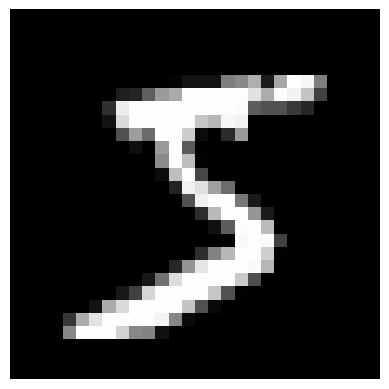

In [4]:
plt.imshow(mnist[0][0].permute(1,2,0), cmap='gray')
plt.axis("off")
plt.show()

In [5]:
_img, _y = mnist[0]
print(_img)
print(_img.min(), _img.max())
print(_y)

tensor([[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1

### **Model Definition**

**Leaky ReLU and Batch Normalization**
<hr>

**Leaky ReLU** is a type of activation function that helps to prevent the function from becoming saturated at 0.<br>
It has a small slope instead of the standard ReLU which has an infinite slope. <br>
Leaky ReLU is a modification of the ReLU activation function. It has the same form as the ReLU, but it will leak some positive values to 0 if they are close enough to zero.<br>
It uses leaky values to avoid dividing by zero when the input value is negative, which can happen with standard ReLU when training neural networks with gradient descent.<br>
Standard ReLU can cause a problem called the “dying ReLU”, where neurons stop learning if they keep outputting 0.

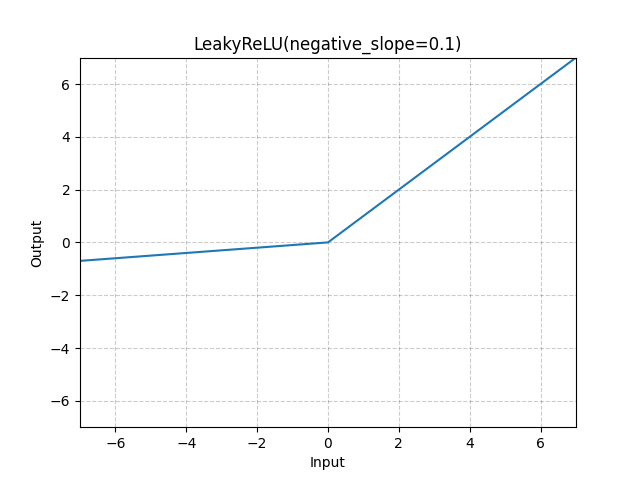


<hr>

**Batch normalization** (also known as batch norm) is a method used to make training of artificial neural networks faster and more stable through normalization of the layers' inputs by re-centering and re-scaling.

In [6]:
class Generator(nn.Module):
  '''
  Generator model definition.
  In the Vanilla GAN it is defined as an MLP model with input size equal to noise vector.
  The output size is the same as images we want to generate.
  '''
  def __init__(self, input_size=NOISE_VECTOR_DIM, output_size=784):
    super(Generator, self).__init__()

    self.model = nn.Sequential(
      nn.Linear(input_size, 128),  #fully connected layer
      nn.LeakyReLU(0.2, inplace=True), #it avoids the problem of 'dead' neurons that can occur with the standard ReLU
      nn.Linear(128, 256),
      nn.BatchNorm1d(256), #Stabilizes and accelerates learning by reducing internal covariate shift
      nn.LeakyReLU(0.2, inplace=True),
      nn.Linear(256, 512),
      nn.BatchNorm1d(512),
      nn.LeakyReLU(0.2, inplace=True),
      nn.Linear(512, 1024),
      nn.BatchNorm1d(1024),
      nn.LeakyReLU(0.2, inplace=True),
      nn.Linear(1024, output_size),
      nn.Tanh() #The tanh activation at the output layer ensures that the pixel
                #values are mapped in line with its own output, i.e., between (-1, 1)
      )


  def forward(self, noise_vector):
    generated_img = self.model(noise_vector)
    generated_img = generated_img.view(generated_img.size(0), 1, 28, 28)
    return generated_img

In [7]:
class Discriminator(nn.Module):
  '''
  Discriminator model definition as a binary classifier.
  In the Vanilla GAN it is defined as an MLP model with input size equal to
  flattened image size.
  The output size is the 1 (i.e. the probability of a binary problem -> real or fake).
  '''
  def __init__(self, input_size=784, num_classes=1):
    super(Discriminator, self).__init__()

    self.model = nn.Sequential(
      nn.Linear(input_size, 512),
      nn.LeakyReLU(0.2, inplace=True),
      nn.Linear(512, 256),
      nn.LeakyReLU(0.2, inplace=True),
      nn.Linear(256, num_classes),
      nn.Sigmoid(), #The final layer has the sigmoid activation function,
                    #which squashes the output value between 0 (fake) and 1 (real).
      )


  def forward(self, image):
    image_flattened = image.view(image.size(0), -1) #-1 tells PyTorch to flatten all the remaining dimensions (in this case 1, 28, 28) into a single dimension.
    result = self.model(image_flattened)
    return result

## **Training phase** (do not execute)

In [8]:
#Models creation
num_samples = 100
D = Discriminator().to(DEVICE)
G = Generator().to(DEVICE)

#Loss function
adversarial_loss  = nn.BCELoss() #Binary Cross Entropy Loss

# Optimizer
# The betas in the Adam optimizer are hyperparameters controlling the
# moving averages of the first moment (mean) and second moment (uncentered variance) of the gradients.
# Setting it to 0.5 (instead of the usual 0.9) helps to smooth out the updates more effectively in the early stages of training, especially in the GAN setup.
D_optimizer = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
G_optimizer = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))


In [9]:
max_epoch = 2 # epochs for training; 2 epochs are not enough to obtain good results
step = 0
n_critic = 1 # for training more k steps about Discriminator

D_loss_history = []
G_loss_history = []

D_labels = torch.ones(BATCH_SIZE, 1).to(DEVICE) # Discriminator Label to real
D_fakes = torch.zeros(BATCH_SIZE, 1).to(DEVICE) # Discriminator Label to fake

# print(D_labels)
# print(D_fakes.shape)
G.train()
D.train()

for epoch in tqdm(range(max_epoch), desc='GAN training', position=0):  # Loop over epochs with a progress bar for better training visualization
  for real_images, _y in tqdm(data_loader, desc=f"Epoch {epoch}", position=1):  # you can use tqdm also in the internal loop if you want view the progress inside each epoch

    # Training Discriminator

    # Discriminator forward pass and loss computation
    x = real_images.to(DEVICE)
    x_outputs = D(x)
    D_x_loss = adversarial_loss(x_outputs, D_labels)

    # noise vector sampled from a normal distribution
    z = torch.randn(BATCH_SIZE, NOISE_VECTOR_DIM).to(DEVICE)
    z_outputs = D(G(z))
    D_z_loss = adversarial_loss(z_outputs, D_fakes)
    D_loss = D_x_loss + D_z_loss

    D.zero_grad() # it delete the gradients accumulated during the training in the previous batch
                  # the training needs to start (in the current batch) with zeroed gradients
    D_loss.backward()
    D_optimizer.step()

    # Training Generator

    if step % n_critic == 0:  #n_critic=1 means the Generator will be trained at every step, right after the Discriminator
      # Training Generator
      z = torch.randn(BATCH_SIZE, NOISE_VECTOR_DIM).to(DEVICE)
      z_outputs = D(G(z))
      G_loss = adversarial_loss(z_outputs, D_labels)

      G.zero_grad()
      G_loss.backward()
      G_optimizer.step()

    if VERBOSE:
      if step % 500 == 0:
        print('Epoch: {}/{}, Step: {}, D Loss: {}, G Loss: {}'.format(epoch, max_epoch, step, D_loss.item(), G_loss.item()))

    G.train()  # swap in training mode; it ensures that G remains in training mode for the next batch.
    step += 1

  D_loss_history.append(D_loss.item())
  G_loss_history.append(G_loss.item())

  # if you want, you could save model checkpoints at each epoch
  # torch.save(G.state_dict(), "G_epoch_{epoch}.pth")
  # torch.save(D.state_dict(), f"D_epoch_{epoch}.pth")

GAN training: 100%|██████████| 2/2 [00:23<00:00, 11.60s/it]


### **Plotting Generator and Discriminator's losses**

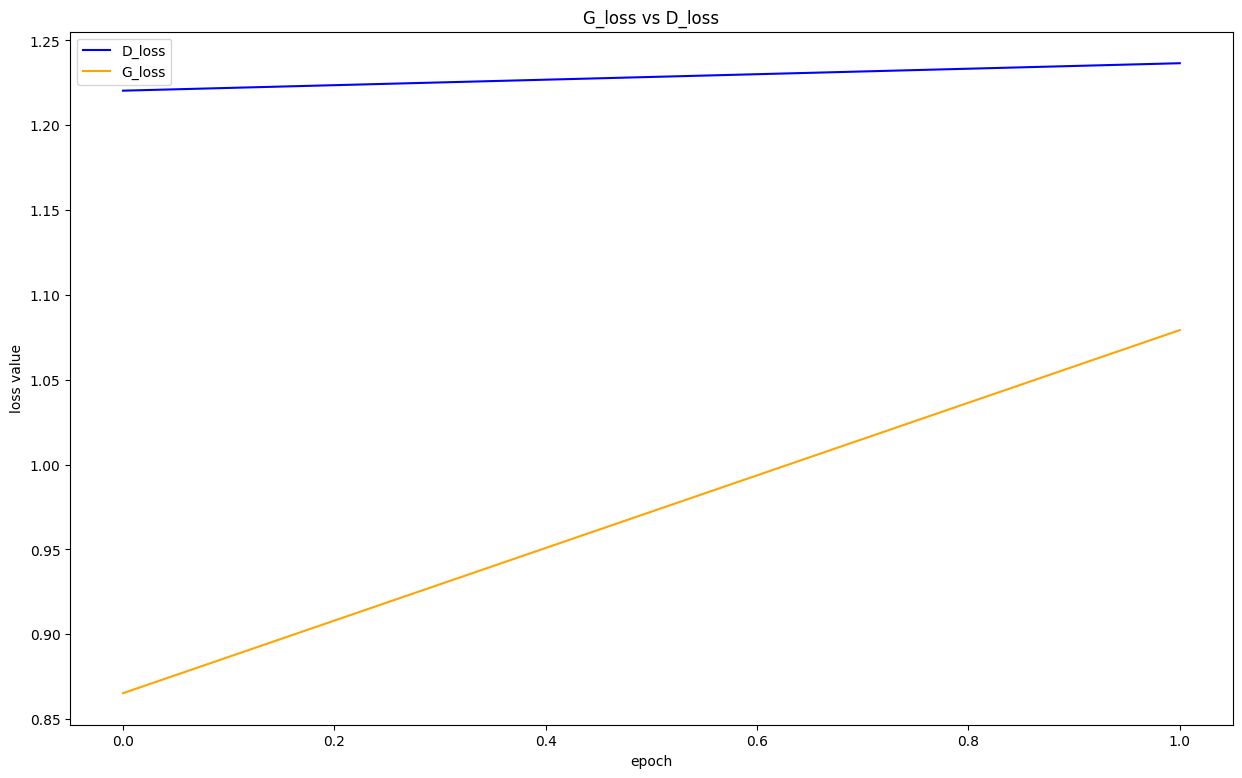

In [10]:
plt.figure(figsize=(15,9))
plt.plot(D_loss_history, color='blue', label='D_loss') #plot the data
plt.plot(G_loss_history, color='orange', label='G_loss') #plot the data
plt.ylabel('loss value') #set the label for y axis
plt.xlabel('epoch') #set the label for x-axis
plt.title("G_loss vs D_loss") #set the title of the graph
plt.legend()
plt.show() #display the graph

In [11]:
# Saving params
min_value = min(G_loss_history)
min_index = G_loss_history.index(min_value)
print(min_index)  #to see at which epoch the Generator has te lowest loss

# Saving models at last epoch of training
torch.save(D.state_dict(), "Discriminator.pth")
torch.save(G.state_dict(), "Generator.pth")

0


#### **Few words about the training phase**

We just skipped the training phase because of time limits.<br>
You have a file named "Generator_210.pth" that is the result of training this GAN using 500 epochs on a RTX PRO 5000 Nvidia GPU for a total time of ~30 min.

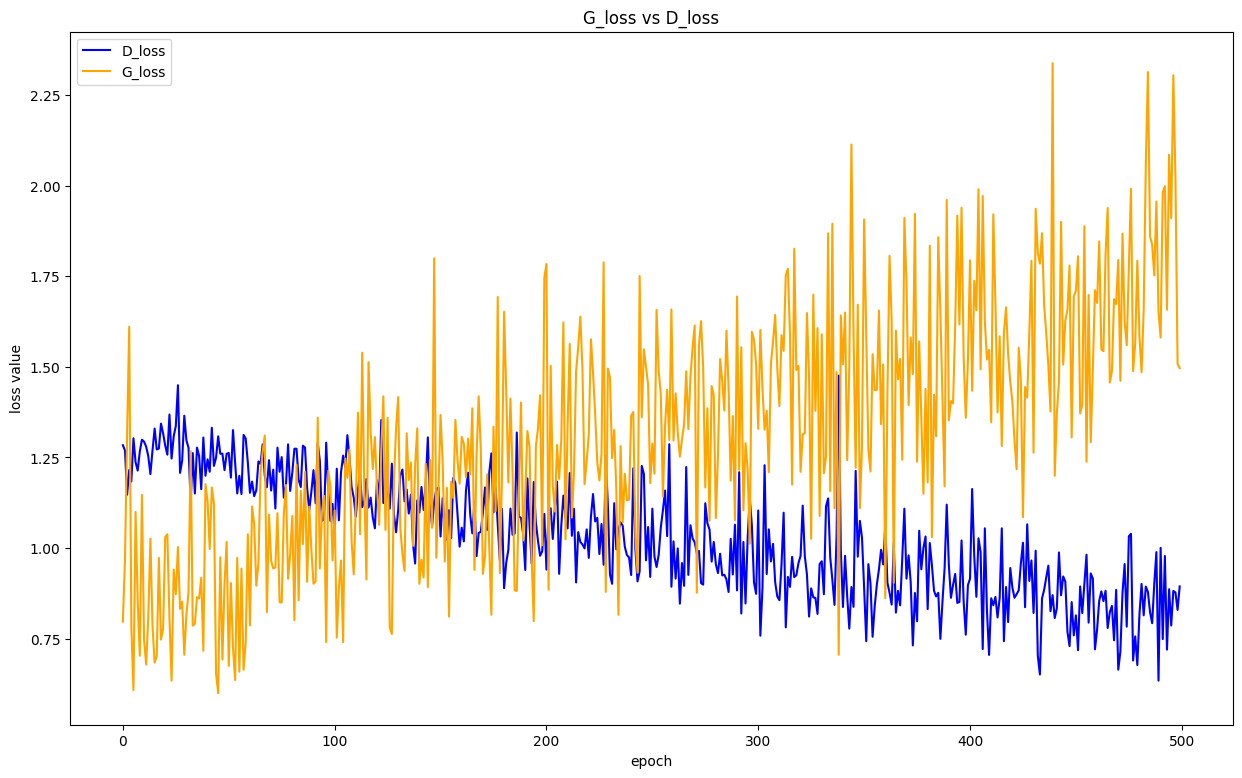

If you want to reproduce training fell free to try!<br>
Below I'll give you some option to start the training:
- Open Google Colab, run the code and pray
- Run the notebook on your local machine
- Use [papermill](https://papermill.readthedocs.io/en/latest/): a tool for parameterizing and executing Jupyter Notebooks from the CLI.

## **Post training operations**

### **Loading model using pytorch**

In [12]:
# Models creation
G = Generator().to(DEVICE)
G.load_state_dict(torch.load('Generator_210.pth', weights_only=True))

print(G.eval())

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Linear(in_features=256, out_features=512, bias=True)
    (6): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Linear(in_features=512, out_features=1024, bias=True)
    (9): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Linear(in_features=1024, out_features=784, bias=True)
    (12): Tanh()
  )
)


### **Generating Samples**

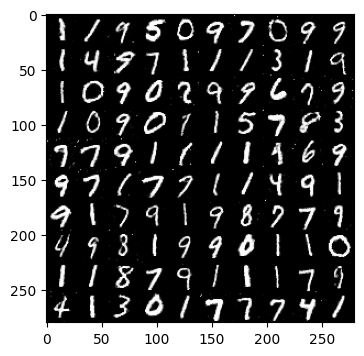

In [13]:
def get_sample_images(G, num_samples):
    '''
    Generate num_samples noise vector from latent space and pass to Generator
    as input in order to get sample images.

    returns:
    num_samples generate images
    '''
    assert int(np.sqrt(num_samples)) * int(np.sqrt(num_samples)) == num_samples  , "num_samples square is not integer"
    #if num_samples is not a perfect square, the program will stop with an AssertionError exception.

    z = torch.randn(num_samples, NOISE_VECTOR_DIM).to(DEVICE)  #z.shape = torch.Size([num_samples, 100])
    y_hat = G(z).view(num_samples, 28, 28) # (100, 28, 28)
    samples_img = y_hat.cpu().data.numpy() # Since y_hat is computed by the neural network G,
                                           # it is not just a simple array of values, but an object with an associated
                                           #computational graph. We access the data attribute to obtain only the
                                           #generated data, which is needed for visualization

    #Put generated samples in a matrix of size sqrt(num_samples) x sqrt(num_samples)
    #in order to plot all samples togheter
    samples_per_line = int(np.sqrt(num_samples))
    matrix_img = np.zeros([28 * samples_per_line, 28 * samples_per_line])
    for j in range(samples_per_line):
        matrix_img[j*28:(j+1)*28] = np.concatenate([x for x in samples_img[j*samples_per_line:(j+1)*samples_per_line]], axis=-1)

    return matrix_img



# generation to image
plt.figure(figsize=(7, 4))
plt.imshow(get_sample_images(G, 100), cmap='gray')
plt.show()